In [1]:
!date

Mon Sep 14 10:53:40 PDT 2026


In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, percentileofscore

projdir = '/u/project/cluo/terencew/claude/project_ideas/pool_design'
sys.path.insert(0, f'{projdir}/scripts/ambisim/lib')
from pool_nomination import load_design_data, universe_idx_for, pool_dist_metrics

In [3]:
### does our pool-construction procedure decouple min_dist/mean_dist the way real
### pools do, or does it entangle them? see NOTES.md (github/demux_pool_design) --
### greedy_maxmin/greedy_maxmean are the same greedy point-repulsion algorithm and
### produce 50-60% the same donor list. This notebook quantifies that directly and
### checks whether the new orthogonal-sampling ('_new') pools actually fix it.
D, X, sample_ids, meta = load_design_data()
UNIVERSE = 'EUR_only'
universe_idx = universe_idx_for(UNIVERSE, meta)
len(universe_idx)

525

In [4]:
### existing n=8 grid pools (already simulated, EUR_only) -- min_dist vs mean_dist
### by strategy, restricted to the ones with real demuxlet data
design = pd.read_csv(f'{projdir}/csv/designs/nominated_pools_n8.tsv', sep='\t')
design['poolid'] = design['universe'] + '__' + design['strategy'] + '__rep' + design['rep'].astype(str)
design = design.drop_duplicates('poolid')[['poolid', 'universe', 'strategy', 'min_dist', 'mean_dist']]

summ = pd.read_csv(f'{projdir}/csv/ambisim/pool_summary.csv', sep='\t')
summ = summ[summ['modality'] == 'gex'].drop_duplicates('pool')[['pool']]
existing = summ.merge(design, left_on='pool', right_on='poolid', how='left')
existing_eur = existing[existing['universe'] == UNIVERSE]
existing_eur[['pool', 'strategy', 'min_dist', 'mean_dist']].sort_values('strategy')

,pool,strategy,min_dist,mean_dist
52,EUR_only__adversarial_family__rep1,adversarial_family,74.202423,101.903511
53,EUR_only__adversarial_family__rep2,adversarial_family,75.808968,101.972603
54,EUR_only__adversarial_family__rep3,adversarial_family,74.652527,102.533302
55,EUR_only__adversarial_mindist__rep1,adversarial_mindist,96.705742,99.814377
56,EUR_only__adversarial_mindist__rep2,adversarial_mindist,95.775780,99.210854
57,EUR_only__greedy_maxkl__rep1,greedy_maxkl,109.311485,112.792702
58,EUR_only__greedy_maxkl__rep2,greedy_maxkl,109.940895,113.561577
59,EUR_only__greedy_maxkl__rep3,greedy_maxkl,110.190742,113.522163
60,EUR_only__greedy_maxmean__rep1,greedy_maxmean,108.646220,114.119960
61,EUR_only__greedy_maxmean__rep3,greedy_maxmean,108.041660,113.974610


In [5]:
### quantify entanglement per strategy family
for strat in ['random', 'greedy_maxmin', 'greedy_maxmean']:
    sub = existing_eur[existing_eur['strategy'] == strat]
    print(f'{strat:15s} n={len(sub)}  min_dist mean={sub.min_dist.mean():.1f}  mean_dist mean={sub.mean_dist.mean():.1f}')

### donor overlap between greedy_maxmin and greedy_maxmean, same rep
for rep in [1, 2, 3]:
    f1 = f'{projdir}/txt/donors/{UNIVERSE}__greedy_maxmin__rep{rep}.txt'
    f2 = f'{projdir}/txt/donors/{UNIVERSE}__greedy_maxmean__rep{rep}.txt'
    try:
        d1 = set(open(f1).read().split())
        d2 = set(open(f2).read().split())
        print(f'rep{rep}: {len(d1 & d2)}/8 donors shared between greedy_maxmin and greedy_maxmean')
    except FileNotFoundError:
        pass

random          n=3  min_dist mean=100.2  mean_dist mean=105.4
greedy_maxmin   n=2  min_dist mean=109.8  mean_dist mean=113.2
greedy_maxmean  n=2  min_dist mean=108.3  mean_dist mean=114.0
rep1: 5/8 donors shared between greedy_maxmin and greedy_maxmean
rep2: 5/8 donors shared between greedy_maxmin and greedy_maxmean
rep3: 6/8 donors shared between greedy_maxmin and greedy_maxmean


In [6]:
### reference backdrop: what does min_dist vs mean_dist look like for pools with
### NO optimization at all? 20k random 8-donor draws, distance-matrix lookups only
### (no genotype simulation) so this is cheap
rng = np.random.default_rng(0)
universe_arr = np.array(universe_idx)
n_draws = 20000
cloud_min, cloud_mean = np.empty(n_draws), np.empty(n_draws)
for i in range(n_draws):
    pool = rng.choice(universe_arr, 8, replace=False)
    m = pool_dist_metrics(list(pool), D)
    cloud_min[i] = m['min_dist']
    cloud_mean[i] = m['mean_dist']

r_cloud, p_cloud = pearsonr(cloud_min, cloud_mean)
print(f'random-draw cloud (n={n_draws}): min_dist vs mean_dist r={r_cloud:.3f} p={p_cloud:.3f}')
print('this is the natural baseline correlation with zero optimization pressure -- compare to')
print('greedy_maxmin/greedy_maxmean r=0.69-0.84 (NOTES.md) and real data r=0.14')

random-draw cloud (n=20000): min_dist vs mean_dist r=0.536 p=0.000
this is the natural baseline correlation with zero optimization pressure -- compare to
greedy_maxmin/greedy_maxmean r=0.69-0.84 (NOTES.md) and real data r=0.14


In [7]:
### load the new orthogonal-sampling ('_new') pools and check where they land
### relative to the random cloud -- do they actually achieve disagreement?
new_design = pd.read_csv(f'{projdir}/csv/designs/nominated_pools_new.tsv', sep='\t')
new_design['pool'] = new_design['pool_name']
for _, row in new_design.iterrows():
    pct_min = percentileofscore(cloud_min, row['min_dist'])
    pct_mean = percentileofscore(cloud_mean, row['mean_dist'])
    print(f"{row['pool']:45s} min_dist={row['min_dist']:6.1f} (p{pct_min:5.1f})   "
          f"mean_dist={row['mean_dist']:6.1f} (p{pct_mean:5.1f})   quadrant={row['quadrant']}")

EUR_only__highmin_lowmean_new__rep1           min_dist= 103.4 (p 98.7)   mean_dist= 105.3 (p 43.8)   quadrant=highmin_lowmean
EUR_only__lowmin_highmean_new__rep1           min_dist=  80.6 (p  0.0)   mean_dist= 106.1 (p 74.7)   quadrant=lowmin_highmean
EUR_only__highmin_lowmean_new__rep2           min_dist= 103.1 (p 97.7)   mean_dist= 105.0 (p 33.9)   quadrant=highmin_lowmean
EUR_only__lowmin_highmean_new__rep2           min_dist=  87.2 (p  0.1)   mean_dist= 107.2 (p 95.3)   quadrant=lowmin_highmean


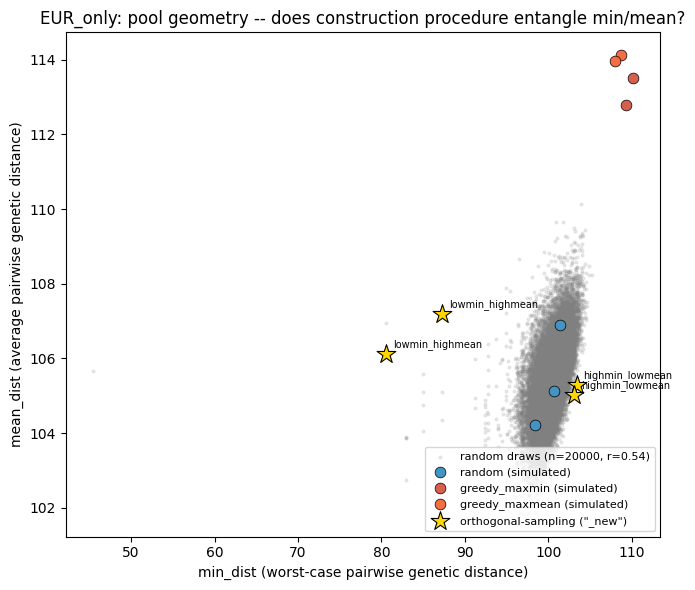

In [8]:
### plot: random cloud (gray) + greedy pools (colored, entangled) + new orthogonal
### pools (stars, should sit off the greedy diagonal in the disagreement corners)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(cloud_min, cloud_mean, s=4, alpha=0.15, color='gray', label=f'random draws (n={n_draws}, r={r_cloud:.2f})')

colors = {'random': '#4393c3', 'greedy_maxmin': '#d6604d', 'greedy_maxmean': '#f46d43'}
for strat, color in colors.items():
    sub = existing_eur[existing_eur['strategy'] == strat]
    ax.scatter(sub['min_dist'], sub['mean_dist'], s=60, color=color, label=f'{strat} (simulated)', edgecolor='black', linewidth=0.5)

ax.scatter(new_design['min_dist'], new_design['mean_dist'], s=200, marker='*', color='gold',
           edgecolor='black', linewidth=0.8, label='orthogonal-sampling ("_new")', zorder=5)
for _, row in new_design.iterrows():
    ax.annotate(row['quadrant'], (row['min_dist'], row['mean_dist']), fontsize=7,
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('min_dist (worst-case pairwise genetic distance)')
ax.set_ylabel('mean_dist (average pairwise genetic distance)')
ax.set_title(f'{UNIVERSE}: pool geometry -- does construction procedure entangle min/mean?')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

In [9]:
### save QC summary for the record
import os
outdir = f'{projdir}/csv/ambisim'
os.makedirs(outdir, exist_ok=True)

qc_rows = [
    {'set': 'random_draw_cloud_n20000', 'n': n_draws, 'min_mean_dist_corr': r_cloud, 'p': p_cloud},
]
for strat in ['random', 'greedy_maxmin', 'greedy_maxmean']:
    sub = existing_eur[existing_eur['strategy'] == strat]
    if len(sub) >= 3:
        r, p = pearsonr(sub['min_dist'], sub['mean_dist'])
        qc_rows.append({'set': strat, 'n': len(sub), 'min_mean_dist_corr': r, 'p': p})

qc_df = pd.DataFrame(qc_rows)
qc_df.to_csv(f'{outdir}/pool_geometry_qc.csv', sep='\t', index=False)
qc_df

,set,n,min_mean_dist_corr,p
0,random_draw_cloud_n20000,20000,0.536363,0.00000
1,random,3,0.882328,0.31195


In [10]:
!date

Mon Sep 14 10:53:47 PDT 2026
